In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import KFold
import numpy as np
import tensorflow as tf
from tensorflow import keras
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)



c:\Users\Samuel\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMA_Train/MA_TRAIN.csv"
path_test  = "dfFinalMA_Test/MA_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 6375 filas, 15 columnas
Dimensiones de Test:  1608 filas, 15 columnas

--- Tipos de datos en Train ---
User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage                bool
Social_Comparison_Trigger       bool
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object

--- Primeras 5 filas de Train ---


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-00061085,19,MALE,PASSIVE SCROLLER,FACEBOOK,4.0,NEWS/POLITICS,PASSIVE,True,False,5.8,8,MILD,8,MILD
1,U-00088ACC,20,MALE,PASSIVE SCROLLER,TIKTOK,4.0,NEWS/POLITICS,PASSIVE,True,False,4.2,10,MODERATE,7,MILD
2,U-000A7FEC,20,MALE,AVERAGE USER,INSTAGRAM,3.6,LIFESTYLE/FASHION,ACTIVE,False,True,6.9,10,MODERATE,0,NONE-MINIMAL
3,U-00228E6E,19,MALE,PASSIVE SCROLLER,YOUTUBE,3.1,LIFESTYLE/FASHION,PASSIVE,False,False,6.2,7,MILD,9,MILD
4,U-00262C0F,18,FEMALE,AVERAGE USER,LINKEDIN,2.4,EDUCATIONAL/TECH,ACTIVE,False,False,6.4,9,MILD,1,NONE-MINIMAL


In [ ]:
# 1. Definir la variable objetivo
le = LabelEncoder()
df_train['PHQ_9_Severity'] = le.fit_transform(df_train['PHQ_9_Severity'])
df_test['PHQ_9_Severity'] = le.transform(df_test['PHQ_9_Severity'])
target_col = "PHQ_9_Severity"

columnas_a_dropear = [
    "User_ID",                 
    "GAD_7_Score",
    "PHQ_9_Score",
    "GAD_7_Severity"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (6375, 10)
Dimensiones de y_train (Objetivo):    (6375,)
Dimensiones de X_test (Predictoras):  (1608, 10)
Dimensiones de y_test (Objetivo):     (1608,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours']


In [ ]:
# 1. Identificar cuáles son las columnas numéricas
# Seleccionamos solo las columnas de tipo entero y decimal
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. AjustaR  y transformar 
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                       -0.0
Daily_Screen_Time_Hours    0.0
Sleep_Duration_Hours       0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                        1.0
Daily_Screen_Time_Hours    1.0
Sleep_Duration_Hours       1.0
dtype: float64

--- Primeras filas de X_train escalado ---


,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours
0,-0.050239,MALE,PASSIVE SCROLLER,FACEBOOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-0.015770
1,0.846880,MALE,PASSIVE SCROLLER,TIKTOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-1.215309
2,0.846880,MALE,AVERAGE USER,INSTAGRAM,-0.281100,LIFESTYLE/FASHION,ACTIVE,False,True,0.808913
3,-0.050239,MALE,PASSIVE SCROLLER,YOUTUBE,-0.498256,LIFESTYLE/FASHION,PASSIVE,False,False,0.284114
4,-0.947357,FEMALE,AVERAGE USER,LINKEDIN,-0.802275,EDUCATIONAL/TECH,ACTIVE,False,False,0.434057


In [ ]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type','Activity_Type']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 21


In [ ]:
# 1. PREPARACIÓN DE DATOS RÁPIDA PARA OPTUNA
# Dividimos tu X_train_codificado en Train y Validación interna
X_tr, X_val, y_tr, y_val = train_test_split(X_train_codificado, y_train, test_size=0.2, random_state=42)

# Convertimos a Tensores (usando tus variables reales)
X_tr_tensor = torch.tensor(X_tr.astype(np.float32).values, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr.astype(np.float32).values, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val.astype(np.float32).values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.astype(np.float32).values, dtype=torch.float32).unsqueeze(1)

# DataLoader
train_loader = DataLoader(TensorDataset(X_tr_tensor, y_tr_tensor), batch_size=64, shuffle=True)

# 2. DEFINIMOS LA FUNCIÓN DE BÚSQUEDA
def objective(trial):
    # --- A. Optuna "adivina" los hiperparámetros ---
    # Le decimos que pruebe entre 1 y 4 capas ocultas
    n_layers = trial.suggest_int('n_layers', 1, 6) 
    # Que pruebe un dropout entre 10% y 50%
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5) 
    # Que pruebe diferentes tasas de aprendizaje (learning rate)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True) 
    
    # --- B. Construimos la red neuronal dinámicamente ---
    layers = []
    in_features = X_train_codificado.shape[1] # Tus 31 columnas de entrada
    
    for i in range(n_layers):
        # Para cada capa, Optuna decide si pone entre 16 y 128 neuronas
        out_features = trial.suggest_int(f'n_units_l{i}', 16, 128) 
        
        layers.append(nn.Linear(in_features, out_features))
        layers.append(nn.BatchNorm1d(out_features))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate))
        
        in_features = out_features # La salida de esta capa es la entrada de la siguiente
        
    # Capa final de salida (1 neurona para predecir el Mental Wellbeing Score)
    layers.append(nn.Linear(in_features, 1))
    
    # Empaquetamos la red
    model = nn.Sequential(*layers)
    
    # --- C. Entrenamos el modelo ---
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    # Entrenamos solo por 100 épocas para que la búsqueda sea rápida
    for epoch in range(100): 
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            
    # --- D. Evaluamos qué tan buena fue esta arquitectura ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor)
        val_loss = criterion(val_preds, y_val_tensor).item() # Calculamos el error
        
    return val_loss # Le decimos a Optuna que su objetivo es minimizar este error

# 3. EJECUTAMOS LA BÚSQUEDA MÁGICA
print("Iniciando búsqueda de la mejor Red Neuronal...")
study = optuna.create_study(direction='minimize')
# Le pedimos que construya y pruebe 20 redes neuronales distintas
study.optimize(objective, n_trials=50) 

print("\n==============================================")
print("¡BÚSQUEDA TERMINADA! LA MEJOR RED NEURONAL ES:")
print("==============================================")
print(study.best_params)

[I 2026-08-28 07:42:15,955] A new study created in memory with name: no-name-7ee997d4-e398-417f-b743-59be18cbf35e


Iniciando búsqueda de la mejor Red Neuronal...


[I 2026-08-28 07:42:31,826] Trial 0 finished with value: 1.4426060914993286 and parameters: {'n_layers': 2, 'dropout_rate': 0.3843090490940071, 'lr': 0.0001688673907996696, 'n_units_l0': 65, 'n_units_l1': 114}. Best is trial 0 with value: 1.4426060914993286.
[I 2026-08-28 07:42:47,184] Trial 1 finished with value: 1.3641481399536133 and parameters: {'n_layers': 1, 'dropout_rate': 0.4406449013797048, 'lr': 0.0001681823386491382, 'n_units_l0': 126}. Best is trial 1 with value: 1.3641481399536133.
[I 2026-08-28 07:43:02,805] Trial 2 finished with value: 1.439663290977478 and parameters: {'n_layers': 1, 'dropout_rate': 0.10637259578002714, 'lr': 0.0015162661456511793, 'n_units_l0': 127}. Best is trial 1 with value: 1.3641481399536133.
[I 2026-08-28 07:43:24,272] Trial 3 finished with value: 1.4234848022460938 and parameters: {'n_layers': 2, 'dropout_rate': 0.27721671362098577, 'lr': 0.00020751628505485245, 'n_units_l0': 100, 'n_units_l1': 94}. Best is trial 1 with value: 1.3641481399536133


¡BÚSQUEDA TERMINADA! LA MEJOR RED NEURONAL ES:
{'n_layers': 1, 'dropout_rate': 0.33241406093464654, 'lr': 0.000219773129313674, 'n_units_l0': 16}


In [ ]:
# ==========================================
# 1. DEFINICIÓN DEL MODELO
# ==========================================

class TabularClassificationModel(nn.Module):

    def __init__(self, num_features):

        super(TabularClassificationModel, self).__init__()

        self.network = nn.Sequential(

            # Capa 1
            nn.Linear(num_features, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.33241406),

            # Salida: 5 clases
            nn.Linear(16, 5)
        )

    def forward(self, x):
        return self.network(x)


# ==========================================
# 2. CONVERTIR TRAIN A TENSORES
# ==========================================

X_train_tensor = torch.tensor(
    X_train_codificado.astype(np.float32).values,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.astype(np.int64).values,
    dtype=torch.long
)


# ==========================================
# 3. CONVERTIR TEST A TENSORES
# ==========================================

X_test_tensor = torch.tensor(
    X_test_codificado.astype(np.float32).values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.astype(np.int64).values,
    dtype=torch.long
)


# ==========================================
# 4. CALCULAR PESOS DE LAS CLASES
# ==========================================

# Contamos cuántos ejemplos hay de cada clase
class_counts = torch.bincount(
    y_train_tensor,
    minlength=5
)

print("Número de ejemplos por clase:")
for i, count in enumerate(class_counts):
    print(f"Clase {i}: {count.item()}")


# Peso inversamente proporcional a la frecuencia
class_weights = len(y_train_tensor) / (
    5 * class_counts.float()
)

print("\nPesos de las clases:")
for i, weight in enumerate(class_weights):
    print(f"Clase {i}: {weight.item():.4f}")


# ==========================================
# 5. CREAR EL MEJOR MODELO
# ==========================================

best_model = TabularClassificationModel(
    num_features=X_train_codificado.shape[1]
)


# ==========================================
# 6. CONFIGURACIÓN DEL ENTRENAMIENTO
# ==========================================

# CrossEntropyLoss ponderada
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


optimizer = optim.AdamW(
    best_model.parameters(),
    lr=0.00021977,
    weight_decay=1e-3
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=15
)


# ==========================================
# 7. DATALOADER
# ==========================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


# ==========================================
# 8. ENTRENAMIENTO FINAL
# ==========================================

max_epochs = 300
patience = 25

best_train_loss = float('inf')
epochs_no_improve = 0

print("\n==============================================")
print("        ENTRENAMIENTO DEL MODELO FINAL")
print("==============================================")


for epoch in range(max_epochs):

    best_model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        logits = best_model(batch_X)

        loss = criterion(
            logits,
            batch_y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    # ==========================================
    # LOSS MEDIO DE LA ÉPOCA
    # ==========================================

    avg_loss = total_loss / len(train_loader)

    scheduler.step(avg_loss)


    # ==========================================
    # EARLY STOPPING
    # ==========================================

    if avg_loss < best_train_loss:

        best_train_loss = avg_loss
        epochs_no_improve = 0

    else:

        epochs_no_improve += 1


    # ==========================================
    # MOSTRAR PROGRESO
    # ==========================================

    if (epoch + 1) % 25 == 0:

        print(
            f"Época {epoch + 1:3d} | "
            f"Loss ponderado: {avg_loss:.4f}"
        )


    if epochs_no_improve >= patience:

        print(
            f"\nEarly Stopping en la época {epoch + 1}"
        )

        break

Número de ejemplos por clase:
Clase 0: 1882
Clase 1: 1018
Clase 2: 278
Clase 3: 3179
Clase 4: 18

Pesos de las clases:
Clase 0: 0.6775
Clase 1: 1.2525
Clase 2: 4.5863
Clase 3: 0.4011
Clase 4: 70.8333

        ENTRENAMIENTO DEL MODELO FINAL
Época  25 | Loss ponderado: 1.3005
Época  50 | Loss ponderado: 1.2291
Época  75 | Loss ponderado: 1.2211
Época 100 | Loss ponderado: 1.1841

Early Stopping en la época 107



       MÉTRICAS EN TEST (RED NEURONAL)
Accuracy  : 50.31%
Precision : 55.07%
Recall    : 50.31%
F1 Score  : 49.79%

              CLASSIFICATION REPORT
                   precision    recall  f1-score   support

             MILD       0.42      0.13      0.20       476
         MODERATE       0.32      0.32      0.32       273
MODERATELY SEVERE       0.13      0.55      0.21        78
     NONE-MINIMAL       0.76      0.79      0.77       777
           SEVERE       0.00      0.00      0.00         4

         accuracy                           0.50      1608
        macro avg       0.33      0.36      0.30      1608
     weighted avg       0.55      0.50      0.50      1608



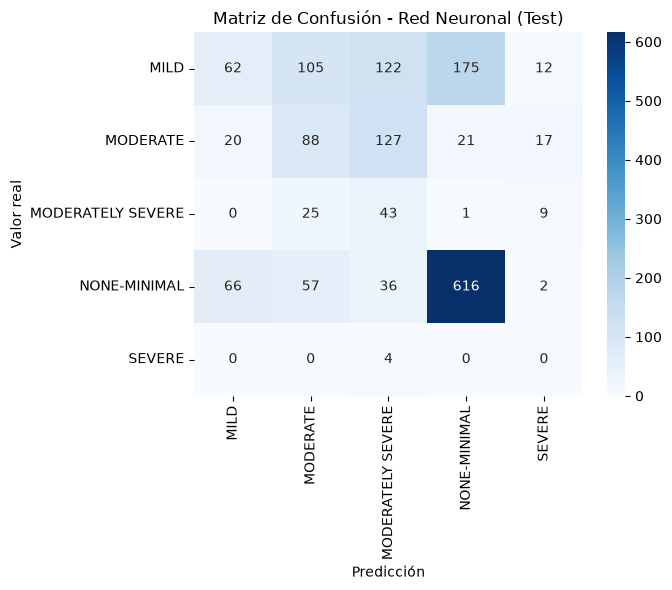

In [ ]:
# ==========================================
# 8. PREDICCIONES SOBRE TEST
# ==========================================

best_model.eval()

with torch.no_grad():

    test_logits = best_model(X_test_tensor)

    # Obtener la clase con mayor probabilidad
    y_pred_tensor = torch.argmax(
        test_logits,
        dim=1
    )


# Convertimos a NumPy
y_pred = y_pred_tensor.numpy()

y_test_np = y_test_tensor.numpy()


# ==========================================
# 9. MÉTRICAS
# ==========================================

accuracy = accuracy_score(
    y_test_np,
    y_pred
)

precision = precision_score(
    y_test_np,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test_np,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test_np,
    y_pred,
    average='weighted'
)


# ==========================================
# 10. MOSTRAR MÉTRICAS
# ==========================================

print("\n==============================================")
print("       MÉTRICAS EN TEST (RED NEURONAL)")
print("==============================================")

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print()


# ==========================================
# 11. CLASSIFICATION REPORT
# ==========================================

print("==============================================")
print("              CLASSIFICATION REPORT")
print("==============================================")

print(
    classification_report(
        y_test_np,
        y_pred,
        target_names=le.classes_
    )
)


# ==========================================
# 12. MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(
    y_test_np,
    y_pred
)


plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.title(
    'Matriz de Confusión - Red Neuronal (Test)'
)

plt.tight_layout()

plt.show()